What this notebook does

In this notebook, I bring churn risk and customer value together to understand which customers are most exposed to churn and what factors are driving their risk.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_xgb = pd.read_csv('xgb_churn_predictions_v3.csv')
df_clv = pd.read_csv('clv_predictions.csv')

In [3]:
print("Churn data:")
display(df_xgb.head())

print("CLV data:")
display(df_clv.head())

Churn data:


,Customer ID,Churn_Probability,Top_Risk_Factor_1,Top_Risk_SHAP_1,Top_Risk_Factor_2,Top_Risk_SHAP_2,Marketing_Insight
0,12346.0,0.401386,Monetary,0.214756,AOV,0.206963,Low historical spending and low average order ...
1,12349.0,0.430360,Purchase_Interval_Std,0.175768,Recency,0.048944,Irregular purchase behavior and long time sinc...
2,12355.0,0.492395,Purchase_Interval_Std,0.180680,Frequency,0.151050,Irregular purchase behavior and low purchase f...
3,12358.0,0.424117,Purchase_Interval_Std,0.175768,Recency,0.050647,Irregular purchase behavior and long time sinc...
4,12359.0,0.249850,Recency,0.046736,NaN,0.000000,Long time since last purchase is increasing ch...


CLV data:


,Customer ID,frequency_cal,monetary_value_cal,expected_avg_spend,CLV_3M,p_alive,clv_segment
0,12346.0,6.0,47.143333,49.192702,86.896749,0.997116,D - Low Value
1,12349.0,1.0,200.000000,247.078364,179.920926,0.939221,D - Low Value
2,12358.0,1.0,268.100000,329.700825,146.092221,0.975062,D - Low Value
3,12359.0,4.0,312.835000,328.167844,397.666401,0.996933,B - High Value
4,12360.0,2.0,331.020000,364.915210,330.351833,0.990236,C - Medium


Before combining the datasets, I check how many customers are present in each one and how many appear in both.

In [4]:
print("Churn customers:", df_xgb["Customer ID"].nunique())
print("CLV customers:", df_clv["Customer ID"].nunique())

common_customers = (
    set(df_xgb["Customer ID"]) &
    set(df_clv["Customer ID"])
)

print("Customers in both datasets:", len(common_customers))

Churn customers: 3377
CLV customers: 2019
Customers in both datasets: 2019


All 2,019 customers with CLV predictions are also present in the churn dataset. These customers are first-time buyers. The churn dataset contains 1,358 additional customers who do not have a CLV prediction.

In [5]:
final_df = df_xgb.merge(
    df_clv,
    on="Customer ID",
    how="left"
)

In [6]:
print("Customers after merge:", final_df["Customer ID"].nunique())
print("Rows after merge:", len(final_df))
print("Missing CLV:", final_df["CLV_3M"].isna().sum())

Customers after merge: 3377
Rows after merge: 3377
Missing CLV: 1358


In [7]:
final_df["Risk_Level"] = np.where(
    final_df["Churn_Probability"] >= 0.35,
    "High Risk",
    "Low Risk"
)

In [8]:
final_df.sample(10)

,Customer ID,Churn_Probability,Top_Risk_Factor_1,Top_Risk_SHAP_1,Top_Risk_Factor_2,Top_Risk_SHAP_2,Marketing_Insight,frequency_cal,monetary_value_cal,expected_avg_spend,clv_3m,p_alive,clv_segment,risk_level
160,12678.0,0.203012,NaN,0.000000,NaN,0.000000,No major behavioral factor is increasing the m...,6.0,1581.701667,1630.062328,3107.168473,0.999357,A - VIP / Whale,Low Risk
969,14105.0,0.448331,Recency,0.213986,Purchase_Interval_Std,0.129470,Long time since last purchase and irregular pu...,1.0,1444.050000,1756.424516,787.775091,0.958192,A - VIP / Whale,High Risk
3005,17618.0,0.215650,Tenure,0.001147,NaN,0.000000,Short customer tenure is increasing churn risk.,5.0,356.056000,369.785286,634.889682,0.998865,B - High Value,Low Risk
2047,15964.0,0.577451,Recency,0.181323,Monetary,0.161016,Long time since last purchase and low historic...,NaN,NaN,NaN,NaN,NaN,NaN,High Risk
2086,16032.0,0.228153,Tenure,0.079707,NaN,0.000000,Short customer tenure is increasing churn risk.,5.0,311.252000,323.348870,1217.700428,0.999303,A - VIP / Whale,Low Risk
1513,15008.0,0.499140,Purchase_Interval_Std,0.190534,Monetary,0.172230,Irregular purchase behavior and low historical...,1.0,240.000000,295.608444,181.865177,0.982916,D - Low Value,High Risk
2917,17471.0,0.538666,Purchase_Interval_Std,0.198152,Monetary,0.174634,Irregular purchase behavior and low historical...,NaN,NaN,NaN,NaN,NaN,NaN,High Risk
2848,17345.0,0.269687,Recency,0.049678,NaN,0.000000,Long time since last purchase is increasing ch...,2.0,219.345000,242.480063,168.316007,0.995257,D - Low Value,Low Risk
852,13897.0,0.520203,Recency,0.191672,Frequency,0.140941,Long time since last purchase and low purchase...,NaN,NaN,NaN,NaN,NaN,NaN,High Risk
2402,16574.0,0.520203,Recency,0.191672,Frequency,0.140941,Long time since last purchase and low purchase...,NaN,NaN,NaN,NaN,NaN,NaN,High Risk


In [8]:
pd.crosstab(
    final_df["Risk_Level"],
    final_df["clv_segment"],
    margins=True
)

clv_segment,A - VIP / Whale,B - High Value,C - Medium,D - Low Value,All
Risk_Level,,,,,
High Risk,54,117,243,424,838
Low Risk,451,387,262,81,1181
All,505,504,505,505,2019


In [9]:
final_df["clv_segment"] = final_df["clv_segment"].fillna(
    "No Repeat Purchase"
)

In [10]:
final_df.groupby("clv_segment")["Churn_Probability"].agg(
    ["min", "max", "mean", "median", "std"]
)

,min,max,mean,median,std
clv_segment,,,,,
A - VIP / Whale,0.192617,0.448331,0.236425,0.201634,0.066741
B - High Value,0.192617,0.501691,0.287574,0.269595,0.079669
C - Medium,0.201634,0.529990,0.355398,0.344135,0.086912
D - Low Value,0.219594,0.618313,0.452437,0.457954,0.084534
No Repeat Purchase,0.359365,0.650150,0.562830,0.567327,0.050732


In [11]:
returning_df = final_df[
    final_df["clv_segment"] != "No Repeat Purchase"
].copy()

In [12]:
segment_summary = returning_df.groupby("clv_segment").agg(
    Customers=("Customer ID", "nunique"),
    Avg_Churn=("Churn_Probability", "mean"),
    Avg_CLV=("CLV_3M", "mean")
)

segment_summary

,Customers,Avg_Churn,Avg_CLV
clv_segment,,,
A - VIP / Whale,505,0.236425,2048.947593
B - High Value,504,0.287574,489.298023
C - Medium,505,0.355398,268.194777
D - Low Value,505,0.452437,114.668090


This gives a useful first view of how customer value and churn risk relate to each other.

In [13]:
high_risk_customers = (
    returning_df[returning_df["Risk_Level"] == "High Risk"]
    .groupby("clv_segment")
    .agg(
        High_Risk_Customers=("Customer ID", "nunique")
    )
)

segment_summary = segment_summary.join(
    high_risk_customers,
    on="clv_segment"
)

In [16]:
segment_summary

,Customers,Avg_Churn,Avg_CLV,High_Risk_Customers
clv_segment,,,,
A - VIP / Whale,505,0.236425,2048.947593,54
B - High Value,504,0.287574,489.298023,117
C - Medium,505,0.355398,268.194777,243
D - Low Value,505,0.452437,114.668090,424


This is useful because average churn risk alone does not show how many customers are actually affected in each segment.

In [14]:
risk_value_matrix = pd.crosstab(
    returning_df["Risk_Level"],
    returning_df["clv_segment"]
)

risk_value_matrix

clv_segment,A - VIP / Whale,B - High Value,C - Medium,D - Low Value
Risk_Level,,,,
High Risk,54,117,243,424
Low Risk,451,387,262,81


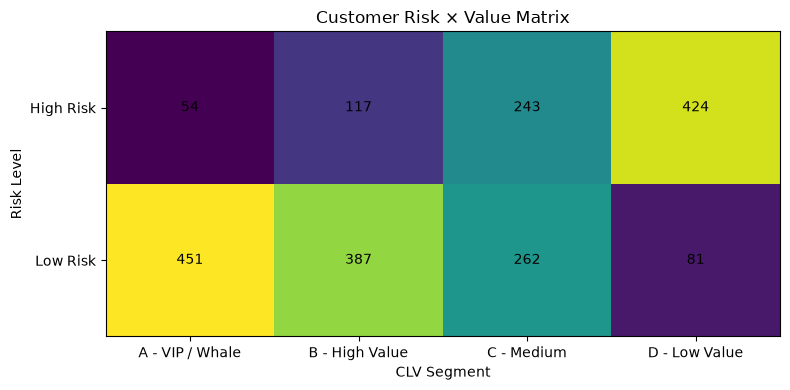

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.imshow(risk_value_matrix, aspect="auto")

plt.xticks(
    range(len(risk_value_matrix.columns)),
    risk_value_matrix.columns
)

plt.yticks(
    range(len(risk_value_matrix.index)),
    risk_value_matrix.index
)

for i in range(len(risk_value_matrix.index)):
    for j in range(len(risk_value_matrix.columns)):
        plt.text(
            j,
            i,
            risk_value_matrix.iloc[i, j],
            ha="center",
            va="center"
        )

plt.title("Customer Risk × Value Matrix")
plt.xlabel("CLV Segment")
plt.ylabel("Risk Level")
plt.tight_layout()
plt.show()

The heatmap makes it much easier to spot where the customers are concentrated and where the bigger retention opportunities might be.

In [17]:
returning_df[["Churn_Probability", "CLV_3M"]].corr()

,Churn_Probability,CLV_3M
Churn_Probability,1.00000,-0.20982
CLV_3M,-0.20982,1.00000


The correlation is -0.21, indicating a weak negative relationship. Risk and value should therefore be considered separately when making retention decisions.

Let's see which factors most often show up as the main reason a customer is flagged as high risk. This gives me a more practical view of the model and helps connect the predictions to possible retention actions.

In [18]:
factor_impact = (
    final_df.groupby("Top_Risk_Factor_1")
    .agg(
        Customers=("Customer ID", "nunique"),
        Avg_SHAP=("Top_Risk_SHAP_1", "mean")
    )
    .sort_values("Avg_SHAP", ascending=False)
)

factor_impact

,Customers,Avg_SHAP
Top_Risk_Factor_1,,
Monetary,843,0.249817
Recency,728,0.178920
Purchase_Interval_Std,835,0.177976
AOV,17,0.070930
Frequency,102,0.030012
Tenure,372,0.010986


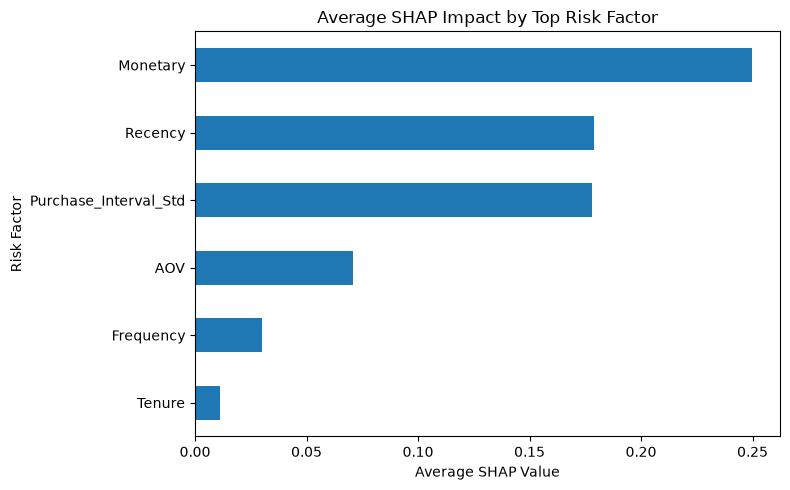

In [19]:
factor_impact["Avg_SHAP"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Average SHAP Impact by Top Risk Factor")
plt.xlabel("Average SHAP Value")
plt.ylabel("Risk Factor")
plt.tight_layout()
plt.show()

In [20]:
vip_df = final_df[
    final_df["clv_segment"] == "A - VIP / Whale"
].copy()

low_df = final_df[
    final_df["clv_segment"] == "D - Low Value"
].copy()

In [21]:
vip_impact = (
    vip_df.groupby("Top_Risk_Factor_1")
    .agg(
        Customers=("Customer ID", "nunique"),
        Avg_SHAP=("Top_Risk_SHAP_1", "mean")
    )
    .sort_values("Avg_SHAP", ascending=False)
)

vip_impact

,Customers,Avg_SHAP
Top_Risk_Factor_1,,
Recency,47,0.191488
Purchase_Interval_Std,51,0.154636
Frequency,11,0.013956
Tenure,149,0.012431


Tenure is the most common top risk factor, while Recency has the strongest average impact. VIP risk drivers differ from those of the overall customer base.

We’ve seen what is putting our VIP customers at risk. Now I want to look at the D - Low Value segment and see whether the risk drivers look different here.

In [22]:
low_impact = (
    low_df.groupby("Top_Risk_Factor_1")
    .agg(
        Customers=("Customer ID", "nunique"),
        Avg_SHAP=("Top_Risk_SHAP_1", "mean")
    )
    .sort_values("Avg_SHAP", ascending=False)
)

low_impact

,Customers,Avg_SHAP
Top_Risk_Factor_1,,
Recency,143,0.195566
Monetary,158,0.193147
Purchase_Interval_Std,156,0.177195
AOV,4,0.107764
Frequency,2,0.014568
Tenure,26,0.004820


The D segment has a different risk pattern from the VIPs. Here, Recency, Monetary, and Purchase_Interval_Std are the main drivers, while Tenure plays a much smaller role.

In [23]:
vip_impact["Segment"] = "VIP"
low_impact["Segment"] = "Low Value"

segment_impact = pd.concat(
    [vip_impact, low_impact]
)

segment_impact

,Customers,Avg_SHAP,Segment
Top_Risk_Factor_1,,,
Recency,47,0.191488,VIP
Purchase_Interval_Std,51,0.154636,VIP
Frequency,11,0.013956,VIP
Tenure,149,0.012431,VIP
Recency,143,0.195566,Low Value
Monetary,158,0.193147,Low Value
Purchase_Interval_Std,156,0.177195,Low Value
AOV,4,0.107764,Low Value
Frequency,2,0.014568,Low Value


I combine CLV with churn probability to estimate how much customer value is potentially at risk.

In [24]:
returning_df["At_Risk_CLV"] = (
    returning_df["CLV_3M"] *
    returning_df["Churn_Probability"]
)

In [25]:
returning_df[
    ["Customer ID", "CLV_3M", "Churn_Probability", "At_Risk_CLV"]
].head()

,Customer ID,CLV_3M,Churn_Probability,At_Risk_CLV
0,12346.0,86.896749,0.401386,34.879140
1,12349.0,179.920926,0.430360,77.430698
3,12358.0,146.092221,0.424117,61.960146
4,12359.0,397.666401,0.249850,99.356831
5,12360.0,330.351833,0.321138,106.088626


In [26]:
clv_at_risk = returning_df.groupby("clv_segment").agg(
    Customers=("Customer ID", "nunique"),
    Total_CLV=("CLV_3M", "sum"),
    CLV_at_Risk=("At_Risk_CLV", "sum")
)

clv_at_risk

,Customers,Total_CLV,CLV_at_Risk
clv_segment,,,
A - VIP / Whale,505,1.034719e+06,232552.800765
B - High Value,504,2.466062e+05,70285.168833
C - Medium,505,1.354384e+05,47636.825748
D - Low Value,505,5.790739e+04,25053.663843


The VIP segment has the highest amount of CLV at risk by a large margin, at around 233K. The lower-value segments have more high-risk customers, but the value attached to each customer is much smaller.

Now let’s look at the percentage of each segment’s CLV that is at risk.

In [28]:
clv_at_risk["CLV_at_Risk_Rate"] = (
    clv_at_risk["CLV_at_Risk"] /
    clv_at_risk["Total_CLV"]
)

clv_at_risk

,Customers,Total_CLV,CLV_at_Risk,CLV_at_Risk_Rate
clv_segment,,,,
A - VIP / Whale,505,1.034719e+06,232552.800765,0.224750
B - High Value,504,2.466062e+05,70285.168833,0.285010
C - Medium,505,1.354384e+05,47636.825748,0.351723
D - Low Value,505,5.790739e+04,25053.663843,0.432651


Let’s make the numbers easier to read.

The waterfall starts with the total projected CLV, then subtracts the CLV at risk from each segment. What is left at the end is the remaining projected CLV.


In [29]:
import plotly.graph_objects as go

total_clv = clv_at_risk["Total_CLV"].sum()

risk_labels = [
    "VIP / Whale at Risk",
    "High Value at Risk",
    "Medium Value at Risk",
    "Low Value at Risk"
]

risk_values = [
    clv_at_risk.loc["A - VIP / Whale", "CLV_at_Risk"],
    clv_at_risk.loc["B - High Value", "CLV_at_Risk"],
    clv_at_risk.loc["C - Medium", "CLV_at_Risk"],
    clv_at_risk.loc["D - Low Value", "CLV_at_Risk"]
]

x_labels = ["Total Projected CLV"] + risk_labels + ["Remaining CLV"]
y_values = [total_clv] + [-value for value in risk_values] + [0]

measure_types = (
    ["absolute"] +
    ["relative"] * len(risk_values) +
    ["total"]
)

fig = go.Figure(
    go.Waterfall(
        orientation="v",
        measure=measure_types,
        x=x_labels,
        y=y_values,
        textposition="outside",
        text=[
            f"${total_clv:,.0f}",
            *[f"-${value:,.0f}" for value in risk_values],
            ""
        ]
    )
)

fig.update_layout(
    title="Projected CLV Exposed to Churn Risk",
    yaxis_title="Projected 3-Month CLV",
    showlegend=False,
    height=600
)

fig.show()